<a href="https://colab.research.google.com/github/mamadou-thiaw/Apprentissage/blob/main/MamdouThiawMiniProjet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mamadou THIAW
# Matricule: XXXXXXXXXXXXXXX

# Projet: Détéction de chute chez les personnes âgées basée sur un réseau de neurone réccurent de type LSTM

Ce projet s'inspire de l'article "**Fall Detection and Activity Recognition Using Human Skeleton Features**", qui propose une méthode de détection des chutes et de reconnaissance d’activités humaines reposant uniquement sur des images vidéo, sans recourir à des capteurs portés ou à des capteurs environnementaux. [lien article](https://ieeexplore.ieee.org/abstract/document/9360751)

La détection des chutes constitue un enjeu majeur de santé publique, en particulier chez les personnes âgées, en raison des conséquences graves parfois fatales qu’elles peuvent entraîner.

Les approches traditionnelles utilisent des capteurs portables (tels que des IMU ou des gyroscopes), mais ces dispositifs s'avèrent souvent inconfortables, intrusifs, et inadaptés aux environnements ouverts ou publics. Les méthodes fondées sur la vision par ordinateur offrent une alternative non invasive. Toutefois, leurs performances ont historiquement été inférieures à celles des approches multi-capteurs.

L’article étudié propose une méthode basée sur la vision, qui exploite les squelettes humains extraits des séquences vidéo à l’aide de AlphaPose. Cette méthode permet de détecter les chutes et de reconnaître diverses activités humaines, même dans des contextes multi-individus.
AlphaPose est utilisé pour extraire 17 points articulaires du squelette humain à partir d’images RGB. Ces points sont ensuite utilisés comme vecteurs de caractéristiques pour l’apprentissage automatique. Quatre algorithmes de classification ont été évalués : Random Forest, SVM, MLP et k-NN, sur le jeu de données public UP-FALL. En classification binaire (chute / non-chute), Random Forest a obtenu les meilleurs résultats avec une précision de 99,34% et un F1-score de 98,52%.

Comme perspective, les auteurs suggèrent d’exploiter des modèles temporels tels que les réseaux de neurones récurrents (LSTM) afin de mieux tirer parti de la dimension séquentielle des données vidéo et de réduire les ambiguïtés entre certaines activités.

**Objectif du projet:**
L’objectif de ce projet est d’intégrer un modèle LSTM pour la détection de chutes, en utilisant comme entrée les squelettes extraits des séquences vidéo. L’hypothèse est que l’exploitation de la dynamique temporelle des articulations permettra d’améliorer la robustesse et la précision du système de détection.



Cette image montre l'architecture proposé par l'article

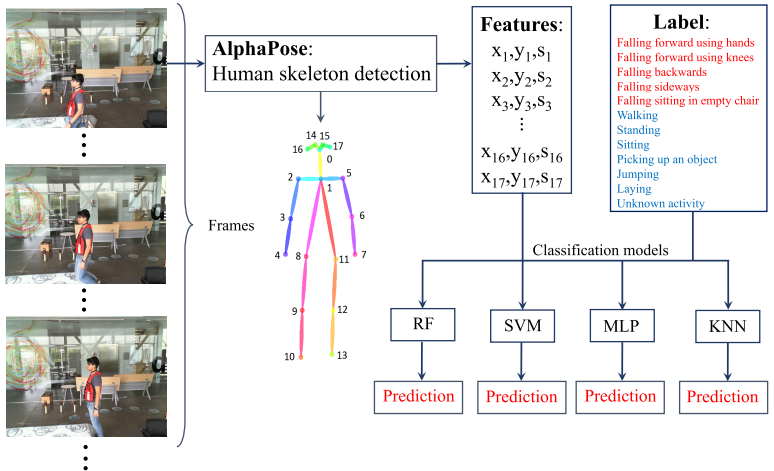

In [ ]:
# Tensorflow
!pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import initializers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
physical_gpus = tf.config.experimental.list_physical_devices("GPU")

In [ ]:
# Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Chagement du dataset UP-FALL**
UP-FALL est un vaste ensemble de données principalement destiné à la détection des chutes, comprenant 11 activités et 3 essais par activité. Les sujets ont effectué six activités quotidiennes(marcher, se tenir debout, soulever un objet, s'asseoir, sauter et s'allonger) humaines simples et cinq chutes (tomber en avant avec les mains, tomber en avant avec les genoux, tomber en arrière, atterrir assis sur une chaise vide et tomber sur le côté) humaines différentes. Ces données ont été collectées auprès de 17 jeunes adultes en bonne santé sans déficience physique, à l'aide d'une approche multimodale, c'est-à-dire de capteurs portables, de capteurs ambiants et de dispositifs de vision.

In [ ]:
# Charger les fichiers
features_inputfile = '/content/drive/My Drive/features_no_repeated.csv'
labels_inputfile = '/content/drive/My Drive/labels_no_repeated.csv'

In [ ]:
features = pd.read_csv(features_inputfile)
labels = pd.read_csv(labels_inputfile)

Les données utilisées dans ce projet proviennent de fichiers CSV prétraités : **features_no_repeated.csv** pour les caractéristiques et **labels_no_repeated.csv** pour les étiquettes. Chaque ligne du fichier features_no_repeated.csv correspond à une image issue d'une séquence vidéo du dataset UP-FALL.

Chaque image est représentée par un vecteur de 51 caractéristiques, correspondant à 17 points articulaires du squelette humain. Pour chaque articulation, trois valeurs sont fournies : la coordonnée X, la coordonnée Y, et un score de confiance. Ces informations sont générées par l'outil d'estimateur de pose AlphaPose.

In [ ]:
features_df = pd.read_csv(features_inputfile)

# Affiche les 5 premières lignes
print(features_df.head(5))

       X_nose      Y_nose  confidence_nose      X_Leye      Y_Leye  \
0  149.510544  421.757507         0.792839  145.946884  416.763184   
1  119.512695  443.534668         0.827928  115.898834  439.920776   
2  174.755447  416.634888         0.807132  171.407181  413.286652   
3  307.365875  364.485901         0.866232  309.469971  360.277679   
4  459.617828  199.020401         0.753503  459.617828  190.354874   

   confidence_Leye      X_Reye      Y_Reye  confidence_Reye      X_Lear  ...  \
0         0.597247  139.530502  423.169495         0.861109  240.478973  ...   
1         0.527712  112.284966  454.376221         0.892755  130.354294  ...   
2         0.576567  164.710678  416.634888         0.905007   91.049171  ...   
3         0.049104  301.053528  360.277679         0.887730  347.343994  ...   
4         0.008810  455.285065  192.521255         0.830895  422.789368  ...   

   confidence_LKnee     X_RKnee     Y_RKnee  confidence_RKnee    X_LAnkle  \
0          0.349181  

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = scaler.fit_transform(features)

# Encodage des labels
Les étiquettes initiales, représentant différentes actions (tomber en avant avec les mains, tomber en avant avec les genoux, tomber en arrière, atterrir assis sur une chaise vide et tomber sur le côté, marcher, se tenir debout, soulever un objet, s'asseoir, sauter et s'allonger), ont été regroupées en deux classes : Fall et Not Fall, pour une détection binaire. Ces étiquettes sont ensuite encodées sous forme numérique (1 = Fall, 0 = Not Fall) à l’aide de la classe LabelEncoder.

In [ ]:
# Conversion préalable du type de la colonne pour autoriser l'affectation de chaînes
labels['label'] = labels['label'].astype(str)

# Fonction de reclassification
def change_labels(l):
    l.loc[l.label.isin(['1.0', '2.0', '3.0', '4.0', '5.0', '11.0']), 'label'] = 'Fall'
    l.loc[l.label.isin(['6.0', '7.0', '8.0', '9.0', '10.0', '20.0']), 'label'] = 'Not Fall'

change_labels(labels)

# Encodage des classes (Fall → 1, Not Fall → 0)
encoder = LabelEncoder()
labels['label'] = encoder.fit_transform(labels['label'])

print(features.shape, labels.shape)

(220660, 51) (220660, 1)


In [ ]:
print(labels['label'].value_counts())  # Doit afficher 0 et 1 uniquement

label
1    171116
0     49544
Name: count, dtype: int64


# Création des séquences temporelles
Afin d’exploiter les capacités du modèle LSTM à modéliser les dynamiques temporelles, les données sont organisées sous forme de séquences successives d’images. La fonction create_sequences permet de transformer la série de vecteurs de caractéristiques extraits des images en une série de séquences fixes.

Chaque séquence est constituée de 20 pas de temps consécutifs (soit 20 images), et est associée à une seule étiquette, correspondant à l’activité observée dans la dernière image de la séquence. Cette méthode permet de capturer l'évolution des postures corporelles dans le temps tout en attribuant à chaque séquence une classe bien définie.

In [ ]:
# Fonction pour découper en séquences
def create_sequences(X, y, seq_length):
    sequences = []
    labels = []
    for i in range(len(X) - seq_length):
        seq = X[i:i+seq_length]
        label = y[i+seq_length-1]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)


sequence_length = 20  # 20 pas de temps par séquence

X = features
y = labels['label'].values

X_seq, y_seq = create_sequences(X, y, sequence_length)

print('X_seq shape:', X_seq.shape)  # (n_sequences, sequence_length, 51)
print('y_seq shape:', y_seq.shape)


X_seq shape: (220640, 20, 51)
y_seq shape: (220640,)


Ici je considère 80% pour l'entraînement et 20% pour le test

In [ ]:
# Séparation du d'entraînement(80%) avec le jeu de test(20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

print('Trainval set:', X_trainval.shape, y_trainval.shape)
print('Test set:', X_test.shape, y_test.shape)

Trainval set: (176512, 20, 51) (176512,)
Test set: (44128, 20, 51) (44128,)


# Achitecture du modèle LSTM
Le modèle proposé repose sur une architecture LSTM comprenant une première couche LSTM de 64 unités, suivie d’une seconde couche LSTM de 32 unités. Ces couches sont suivies d’une couche dense intermédiaire de 16 neurones avec une activation ReLU, puis d’une couche de sortie comportant une seule unité avec une activation sigmoïde, adaptée à la classification binaire (chute / non-chute).

L'entraînement est réalisé à l’aide de l’optimiseur Adam (taux d’apprentissage = 0.0001) et de la fonction de perte binary cross-entropy.
Une validation croisée à 3 plis est utilisée (KFold), accompagnée d’un arrêt anticipé (EarlyStopping) pour éviter le surapprentissage, et d’un mécanisme de sauvegarde (ModelCheckpoint) afin de conserver le modèle ayant les meilleures performances sur les données de validation.

In [ ]:
import time

# Validation croisée
n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

acc_per_fold = []
loss_per_fold = []
fold_no = 1

for train_idx, val_idx in kf.split(X_trainval, y_trainval):
    print(f'\nTraining for fold {fold_no}...')


    X_train, X_val = X_trainval[train_idx], X_trainval[val_idx]
    y_train, y_val = y_trainval[train_idx], y_trainval[val_idx]

    # Création du modèle LSTM
    model = models.Sequential([
        layers.Input(shape=(sequence_length, 51)),
        layers.LSTM(64, return_sequences=True, kernel_initializer=initializers.HeNormal()),
        layers.LSTM(32),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )


    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        # Callback pour sauvegarder le meilleur modèle
    checkpoint_callback = ModelCheckpoint(
        '/content/drive/My Drive/best_model.keras',  # Sauvegarde le modèle à cet emplacement
        monitor='val_loss',  # Suivre la perte sur le jeu de validation
        save_best_only=True,  # suavegarde seulement le meilleur modèle
        mode='min',  # Minimiser la perte
        verbose=0
    )

    # Temps d'entraînement
    start_time = time.time()

    # Entraînement du modèle LSTM
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        callbacks=[callback,checkpoint_callback],
        verbose=2
    )


    end_time = time.time()
    training_time = end_time - start_time

    print(f'Temps d\'entraînement pour le fold {fold_no}: {training_time:.2f} secondes')

    # Sauvegarder les résultats pour chaque fold
    scores = model.evaluate(X_val, y_val, verbose=0)
    print(f'Score for fold {fold_no}: {model.metrics_names[0]} = {scores[0]:.4f}; {model.metrics_names[1]} = {scores[1]*100:.2f}%')
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    fold_no += 1



Training for fold 1...
Epoch 1/15
3678/3678 - 39s - 10ms/step - accuracy: 0.9677 - loss: 0.0963 - val_accuracy: 0.9859 - val_loss: 0.0359
Epoch 2/15
3678/3678 - 39s - 11ms/step - accuracy: 0.9887 - loss: 0.0286 - val_accuracy: 0.9900 - val_loss: 0.0253
Epoch 3/15
3678/3678 - 32s - 9ms/step - accuracy: 0.9914 - loss: 0.0224 - val_accuracy: 0.9915 - val_loss: 0.0215
Epoch 4/15
3678/3678 - 42s - 12ms/step - accuracy: 0.9922 - loss: 0.0194 - val_accuracy: 0.9912 - val_loss: 0.0209
Epoch 5/15
3678/3678 - 38s - 10ms/step - accuracy: 0.9933 - loss: 0.0173 - val_accuracy: 0.9924 - val_loss: 0.0183
Epoch 6/15
3678/3678 - 34s - 9ms/step - accuracy: 0.9939 - loss: 0.0157 - val_accuracy: 0.9934 - val_loss: 0.0168
Epoch 7/15
3678/3678 - 30s - 8ms/step - accuracy: 0.9946 - loss: 0.0142 - val_accuracy: 0.9936 - val_loss: 0.0161
Epoch 8/15
3678/3678 - 34s - 9ms/step - accuracy: 0.9951 - loss: 0.0128 - val_accuracy: 0.9940 - val_loss: 0.0153
Epoch 9/15
3678/3678 - 41s - 11ms/step - accuracy: 0.9956 - 

In [ ]:
# Visualisation de l'architecture du modèle LSTM
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 20, 64)         │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,973 (499.90 KB)

 Trainable params: 42,657 (166.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 85,316 (333.27 KB)

# Évaluation du meilleur modèle sur le jeu de test
 Le meilleur modèle, évalué sur le jeu de test a atteint une accuracy de **99,52%** et une perte de **0,0125** surpassant celui obtenu par l'article. Ces résultats illustrent la robustesse du modèle LSTM dans la tâche de détection binaire des chutes.

In [ ]:
# ÉVALUATION FINALE SUR TEST SET
print("\nÉvaluation sur le jeu de test...")

# Chargement du meilleur modèle
best_model = tf.keras.models.load_model('/content/drive/My Drive/best_model.keras')

# Évaluation avec le meilleur modèle
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=2)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy*100:.2f}%')


Évaluation sur le jeu de test...
1379/1379 - 7s - 5ms/step - accuracy: 0.9952 - loss: 0.0125
Test Loss: 0.0125
Test Accuracy: 99.52%


In [ ]:
# Prédictions
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

1379/1379 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


# Métriques de performance et matrice de confusion
L’évaluation finale du modèle LSTM sur le jeu de test montre que 34160 chutes ont été correctement détectées (Vrais positifs - TP), tandis que 63 cas de chute n'ont pas été détectés (Faux négatifs - FN). De plus, 9757 cas de non-chute ont été correctement identifiés (Vrais négatifs - TN) et 148 cas de non-chute ont été faussement prédits comme des chutes (Faux positifs - FP).

On observe également une précision et un rappel de 100 % pour la classe "Fall", ce qui signifie que toutes les chutes ou presque ont été correctement identifiées, avec aucune chute significative oubliée. Le F1-score global atteint 1.00, ce qui reflète un équilibre parfait entre précision et rappel.

Le taux d'erreur sur la classe "Not Fall" est extrêmement faible, avec seulement 148 faux positifs sur 9 905 cas, soit environ 1,5%.

Ces résultats confirment l’efficacité du modèle LSTM proposé, qui exploite la dynamique temporelle des articulations squelettiques extraites des séquences vidéo. Le modèle surpasse les performances obtenues dans l’article de référence basé sur des classificateurs classiques. Il constitue ainsi une solution robuste et non invasive pour la détection de chutes, adaptée à des déploiements en environnements réels (domicile, hôpitaux, lieux publics), où chaque erreur de détection peut avoir des conséquences graves.

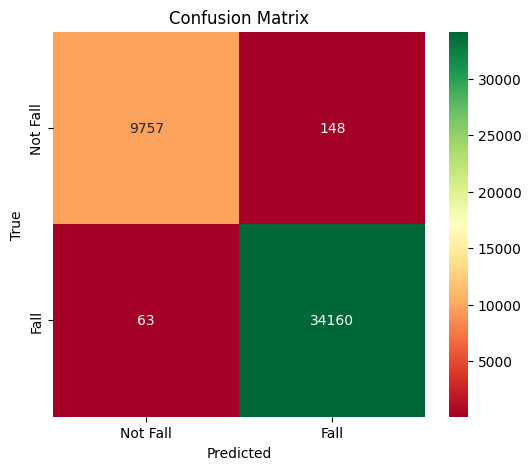


Classification Report:
              precision    recall  f1-score   support

    Not Fall       0.99      0.99      0.99      9905
        Fall       1.00      1.00      1.00     34223

    accuracy                           1.00     44128
   macro avg       0.99      0.99      0.99     44128
weighted avg       1.00      1.00      1.00     44128



In [ ]:
# MATRICE DE CONFUSION
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='RdYlGn', xticklabels=['Not Fall', 'Fall'], yticklabels=['Not Fall', 'Fall'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# Rapport de classification
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Fall', 'Fall']))

# Courbe d'apprentissage

D’après les courbes d’apprentissage, on observe:

D’une part, une diminution rapide des courbes de perte (perte d’entraînement et perte de validation). La perte d’entraînement chute de 0,08 à moins de 0,01, tandis que la perte de validation suit une trajectoire très proche, sans écart significatif. Ce comportement indique que le modèle apprend efficacement, sans signe apparent de surapprentissage (overfitting).

D’autre part, la précision d’entraînement progresse de 97,4 % à plus de 99,8 %, et la précision de validation suit quasiment la même tendance, atteignant un plateau autour de 99,5 %. Cela montre que le modèle est stable, robuste, et qu’il généralise bien aux nouvelles données.


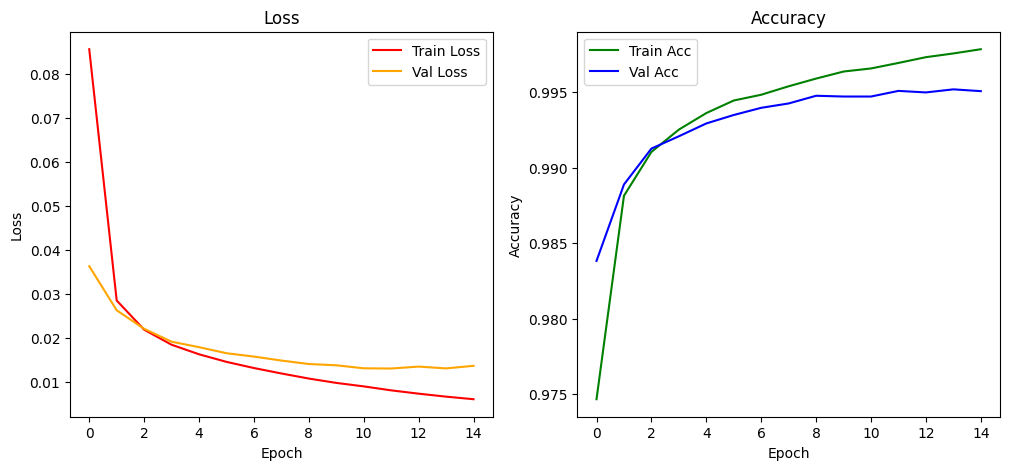

In [ ]:
# COURBES DE PERFORMANCE
plt.figure(figsize=(12,5))

# Courbe Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss',color= 'orange')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Courbe Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc', color='green')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='blue')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# Conclusion générale

L’objectif de ce projet était de développer un modèle de détection de chutes basé sur un réseau de neurones récurrent de type LSTM, en utilisant le jeu de données public UP-Fall et en s’inspirant de l’article “**Fall Detection and Activity Recognition Using Human Skeleton Features**”.

Les caractéristiques squelettiques ont été extraites à partir d’images vidéo à l’aide de l’outil AlphaPose, puis structurées en séquences temporelles pour être traitées par le modèle LSTM. Contrairement à l’approche de l’article original, qui utilisait des classificateurs statiques comme le Random Forest, le KNN, SVM, et MPL, mon approche tire pleinement parti des dépendances temporelles entre les postures, caractéristiques essentielles dans la dynamique d’une chute.

Le modèle proposé a obtenu d’excellents résultats avec une accuracy de 99,52% et un F1-score de 1.00, surpassant ainsi les performances rapportées dans l’article de référence (accuracy de 99,34% et F1-score de 98,52%). Ces résultats mettent en évidence la puissance du LSTM à modéliser des séquences de mouvements humains pour des tâches critiques comme la détection de chutes.